# **Loan Credit Risk Analytics & Lending Portfolio Intelligence**

# **Project Overview**

Financial institutions process thousands of loan applications daily while balancing profitability against credit risk. Poor lending decisions increase default rates, reduce portfolio quality, and negatively affect overall financial performance.

This project develops an **end-to-end loan credit risk analytics solution** using **Python** for data cleaning, exploratory analysis, feature engineering, and KPI development, while **Tableau** is used to build interactive executive dashboards for business decision-making.

The project transforms raw lending data into actionable business intelligence that supports **credit risk management, portfolio optimization, and strategic lending decisions.**

---

# **Business Problem**

Financial institutions continually face critical lending questions, including:

- Which borrowers are most likely to default?
- Which customer segments generate the highest profitability?
- Which loan grades contribute the greatest financial risk?
- Which loan purposes produce the highest expected interest income?
- How can lending policies reduce defaults while maximizing revenue?

Without a structured analytical framework, answering these questions becomes difficult, leading to higher credit losses, poor portfolio performance, and suboptimal lending decisions.

---

# **Objectives**

This project aims to:

- Perform a comprehensive **Exploratory Data Analysis (EDA)** on a large-scale lending dataset.
- Engineer meaningful borrower and financial risk features.
- Develop business-driven **Key Performance Indicators (KPIs)**.
- Identify the primary drivers of loan default.
- Segment borrowers according to financial behaviour and credit quality.
- Evaluate portfolio profitability and lending performance.
- Build interactive executive dashboards that support strategic lending decisions.

---

# **Scope**

The project covers the complete analytics lifecycle:

- **Data Cleaning**
- **Data Validation**
- **Exploratory Data Analysis (EDA)**
- **Feature Engineering**
- **KPI Intelligence**
- **Business Intelligence**
- **Dashboard Development (Tableau)**
- **Executive Insights**
- **Business Recommendations**

---

### Importing Libraries

In [148]:
#Importing Libraries...
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ssl
import io
import requests
import zipfile

## Loading Datasets and Data cleaning

In [149]:
#1. Assign and read Loan Credit Risk Dataset as csv file
url = "https://raw.githubusercontent.com/Esters-10/loan-credit-risk-analytics/main/data/lending_club_loan.csv.zip"
response = requests.get(url)

In [150]:
with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    print("Files inside zip:", z.namelist())

    with z.open(z.namelist()[0]) as f:
        loan_credit = pd.read_csv(f)

Files inside zip: ['lending_club_loan.csv', '__MACOSX/._lending_club_loan.csv']


In [151]:
loan_credit.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,loan_status,purpose,dti,open_acc,revol_bal,revol_util,total_acc,application_type,mort_acc,pub_rec_bankruptcies
0,10000,36 months,11.44,329.48,B,B4,10+ years,RENT,117000.0,Not Verified,...,Fully Paid,vacation,26.24,16,36369,41.8,25,INDIVIDUAL,0.0,0.0
1,8000,36 months,11.99,265.68,B,B5,4 years,MORTGAGE,65000.0,Not Verified,...,Fully Paid,debt_consolidation,22.05,17,20131,53.3,27,INDIVIDUAL,3.0,0.0
2,15600,36 months,10.49,506.97,B,B3,< 1 year,RENT,43057.0,Source Verified,...,Fully Paid,credit_card,12.79,13,11987,92.2,26,INDIVIDUAL,0.0,0.0
3,7200,36 months,6.49,220.65,A,A2,6 years,RENT,54000.0,Not Verified,...,Fully Paid,credit_card,2.60,6,5472,21.5,13,INDIVIDUAL,0.0,0.0
4,24375,60 months,17.27,609.33,C,C5,9 years,MORTGAGE,55000.0,Verified,...,Charged Off,credit_card,33.95,13,24584,69.8,43,INDIVIDUAL,1.0,0.0


In [152]:
loan_credit.info()

<class 'pandas.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 21 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  int64  
 1   term                  396030 non-null  str    
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  str    
 5   sub_grade             396030 non-null  str    
 6   emp_length            377729 non-null  str    
 7   home_ownership        396030 non-null  str    
 8   annual_inc            396030 non-null  float64
 9   verification_status   396030 non-null  str    
 10  issue_d               396030 non-null  str    
 11  loan_status           396030 non-null  str    
 12  purpose               396030 non-null  str    
 13  dti                   396030 non-null  float64
 14  open_acc              396030 non-null  int64  
 15  revol_bal  

In [153]:
## Remove irrelevant columns
loan_credit = loan_credit.drop(columns=[
    'sub_grade',
    'mort_acc'
])

In [154]:
#Generate loan_id synthetically
loan_credit['loan_id']= [
    f'LOAN{i:06d}'
    for i in range(1, len(loan_credit)+1)
]

In [155]:
#Generate and randomize customer_id synthetically
loan_credit['customer_id'] = [
    f'CUST_{i:06d}'
    for i in range(1, len(loan_credit)+1)
]

In [156]:
#re-arrange column heading
cols = ['loan_id', 'customer_id'] + [col for col in loan_credit.columns if col not in ['loan_id', 'customer_id']]

loan_credit = loan_credit[cols]

In [157]:
loan_credit.columns

Index(['loan_id', 'customer_id', 'loan_amnt', 'term', 'int_rate',
       'installment', 'grade', 'emp_length', 'home_ownership', 'annual_inc',
       'verification_status', 'issue_d', 'loan_status', 'purpose', 'dti',
       'open_acc', 'revol_bal', 'revol_util', 'total_acc', 'application_type',
       'pub_rec_bankruptcies'],
      dtype='str')

In [158]:
loan_credit.info()

<class 'pandas.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 21 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_id               396030 non-null  str    
 1   customer_id           396030 non-null  str    
 2   loan_amnt             396030 non-null  int64  
 3   term                  396030 non-null  str    
 4   int_rate              396030 non-null  float64
 5   installment           396030 non-null  float64
 6   grade                 396030 non-null  str    
 7   emp_length            377729 non-null  str    
 8   home_ownership        396030 non-null  str    
 9   annual_inc            396030 non-null  float64
 10  verification_status   396030 non-null  str    
 11  issue_d               396030 non-null  str    
 12  loan_status           396030 non-null  str    
 13  purpose               396030 non-null  str    
 14  dti                   396030 non-null  float64
 15  open_acc   

In [159]:
#Checking null values
loan_credit[['emp_length', 'revol_util', 'pub_rec_bankruptcies']].isnull().sum()  

emp_length              18301
revol_util                276
pub_rec_bankruptcies      535
dtype: int64

In [160]:
loan_credit['emp_length'].value_counts()

emp_length
10+ years    126041
2 years       35827
< 1 year      31725
3 years       31665
5 years       26495
1 year        25882
4 years       23952
6 years       20841
7 years       20819
8 years       19168
9 years       15314
Name: count, dtype: int64

In [161]:
#Fill 'emp_length' null values with mode
loan_credit['emp_length'] = loan_credit['emp_length'].fillna(loan_credit['emp_length'].mode()[0])
loan_credit['emp_length'].isnull().sum()

np.int64(0)

In [162]:
loan_credit['revol_util'].describe()

count    395754.000000
mean         53.791749
std          24.452193
min           0.000000
25%          35.800000
50%          54.800000
75%          72.900000
max         892.300000
Name: revol_util, dtype: float64

In [163]:
#Fill 'revol_util' null values with mean
loan_credit['revol_util'] = loan_credit['revol_util'].fillna(loan_credit['revol_util'].mean())
loan_credit['revol_util'].isnull().sum()

np.int64(0)

In [164]:
loan_credit['pub_rec_bankruptcies'].value_counts()

pub_rec_bankruptcies
0.0    350380
1.0     42790
2.0      1847
3.0       351
4.0        82
5.0        32
6.0         7
7.0         4
8.0         2
Name: count, dtype: int64

In [165]:
#Fill 'pub_rec_bankruptcies' null values with mode
loan_credit['pub_rec_bankruptcies'] = loan_credit['pub_rec_bankruptcies'].fillna(
    loan_credit['pub_rec_bankruptcies'].mode()[0]
)
loan_credit['pub_rec_bankruptcies'].isnull().sum()

np.int64(0)

In [166]:
loan_credit.head()

,loan_id,customer_id,loan_amnt,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,...,issue_d,loan_status,purpose,dti,open_acc,revol_bal,revol_util,total_acc,application_type,pub_rec_bankruptcies
0,LOAN000001,CUST_000001,10000,36 months,11.44,329.48,B,10+ years,RENT,117000.0,...,Jan-15,Fully Paid,vacation,26.24,16,36369,41.8,25,INDIVIDUAL,0.0
1,LOAN000002,CUST_000002,8000,36 months,11.99,265.68,B,4 years,MORTGAGE,65000.0,...,Jan-15,Fully Paid,debt_consolidation,22.05,17,20131,53.3,27,INDIVIDUAL,0.0
2,LOAN000003,CUST_000003,15600,36 months,10.49,506.97,B,< 1 year,RENT,43057.0,...,Jan-15,Fully Paid,credit_card,12.79,13,11987,92.2,26,INDIVIDUAL,0.0
3,LOAN000004,CUST_000004,7200,36 months,6.49,220.65,A,6 years,RENT,54000.0,...,Nov-14,Fully Paid,credit_card,2.60,6,5472,21.5,13,INDIVIDUAL,0.0
4,LOAN000005,CUST_000005,24375,60 months,17.27,609.33,C,9 years,MORTGAGE,55000.0,...,Apr-13,Charged Off,credit_card,33.95,13,24584,69.8,43,INDIVIDUAL,0.0


## Data Quality Engineering

In [167]:
#Create a function to standardize columns
def clean_columns(df):
    df.columns= (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(' ', '_')
        .str.replace('-', '_')
    )
    return df  

In [168]:
loan_credit = clean_columns(loan_credit)

In [169]:
loan_credit.info()

<class 'pandas.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 21 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_id               396030 non-null  str    
 1   customer_id           396030 non-null  str    
 2   loan_amnt             396030 non-null  int64  
 3   term                  396030 non-null  str    
 4   int_rate              396030 non-null  float64
 5   installment           396030 non-null  float64
 6   grade                 396030 non-null  str    
 7   emp_length            396030 non-null  str    
 8   home_ownership        396030 non-null  str    
 9   annual_inc            396030 non-null  float64
 10  verification_status   396030 non-null  str    
 11  issue_d               396030 non-null  str    
 12  loan_status           396030 non-null  str    
 13  purpose               396030 non-null  str    
 14  dti                   396030 non-null  float64
 15  open_acc   

In [170]:
#Change invalid loan_credit data type
loan_credit['term'] = loan_credit['term'].str.replace('months', ' ').astype('int')
loan_credit['issue_d'] = pd.to_datetime(loan_credit['issue_d'])


/var/folders/x7/xwx5c34s1wd5qfqvv63xy2mm0000gp/T/ipykernel_809/2298161055.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  loan_credit['issue_d'] = pd.to_datetime(loan_credit['issue_d'])


In [171]:
# Select the columns and convert them to 'category' type
cols_to_fix = ['grade', 'home_ownership', 'verification_status', 'loan_status', 'purpose', 'application_type']

loan_credit[cols_to_fix] = loan_credit[cols_to_fix].astype('category')   

In [172]:
#Check duplicate values in primary keys
loan_credit.duplicated().sum()

np.int64(0)

In [173]:
loan_credit['loan_id'].duplicated().sum()

np.int64(0)

In [174]:
##Primary Key Uniqueness
loan_credit['loan_id'].is_unique

True

In [175]:
#Create realistic (unique and multiple) customer_id distribution (unique and multiple) 
np.random.seed(42)

num_of_loans = len(loan_credit)

loan_distribution = {
    1: 0.75,
    2: 0.18,
    3: 0.05,
    4: 0.015,
    5: 0.005
}

##Create customer pool
customer_pool = []

customer_number = 1
total_loans = 0

while total_loans < num_of_loans:
    loans = np.random.choice(
        list(loan_distribution.keys()),
        p=list(loan_distribution.values())
    )
    if total_loans + loans > num_of_loans:
        loans = num_of_loans - total_loans

    customer_id = f"CUST_{customer_number:06d}"
    customer_pool.extend([customer_id] * loans)

    total_loans += loans
    customer_number += 1

In [176]:
##Shuffle and assign customer_id list
np.random.shuffle(customer_pool)
loan_credit['customer_id'] = customer_pool

In [177]:
##Standardize customer information (make them consistent)
customer_columns = [
    "annual_inc",
    "emp_length",
    "home_ownership",
    "verification_status",
    "grade",
    "application_type",
    "pub_rec_bankruptcies"    
]

loan_credit[customer_columns] = (
    loan_credit.groupby('customer_id')[customer_columns].transform("first")
)

In [178]:
for col in customer_columns:
    inconsistent_data = (
        loan_credit.groupby('customer_id')[col].nunique().gt(1).sum()
    )
    print(f"{col}: {inconsistent_data} inconsistent customers")

annual_inc: 0 inconsistent customers
emp_length: 0 inconsistent customers
home_ownership: 0 inconsistent customers
verification_status: 0 inconsistent customers
grade: 0 inconsistent customers
application_type: 0 inconsistent customers
pub_rec_bankruptcies: 0 inconsistent customers


In [179]:
## Create debt to annual_inc ratio (percent) based on my dataset

#- Check if customers have unique income
income_check = (
    loan_credit.groupby("customer_id")["annual_inc"]
    .nunique()
)

print((income_check > 1).sum())

0


In [180]:
#- create a new Debt_annual_inc_ratio
loan_credit['debt_annual_inc_ratio'] = (
    loan_credit.groupby("customer_id")["loan_amnt"]
    .transform("sum")
    /loan_credit.groupby("customer_id")["annual_inc"]
    .transform("first")
) * 100

In [181]:
loan_credit['debt_annual_inc_ratio'].describe()

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


count    3.960300e+05
mean              inf
std               NaN
min      3.090095e-02
25%      1.726636e+01
50%      2.906977e+01
75%      4.718978e+01
max               inf
Name: debt_annual_inc_ratio, dtype: float64

In [182]:
##Noticed inf values, check how many and possible cause
(loan_credit["annual_inc"] == 0).sum()

np.int64(1)

In [183]:
## Properly inspect record
loan_credit.loc[
    loan_credit["annual_inc"] == 0,
    ["customer_id", "loan_amnt", "annual_inc", "loan_status", "debt_annual_inc_ratio"]
]

,customer_id,loan_amnt,annual_inc,loan_status,debt_annual_inc_ratio
285674,CUST_038609,3700,0.0,Charged Off,inf


In [184]:
## Decision:
## Remove that data since it is about statistically insignificant

loan_credit = loan_credit[loan_credit["annual_inc"] > 0]

In [185]:
##Re-check Debt_annual_inc_ratio (percent)
loan_credit['debt_annual_inc_ratio'].describe()

count    396029.000000
mean         39.051821
std          35.725914
min           0.030901
25%          17.266187
50%          29.069767
75%          47.189781
max        1535.000000
Name: debt_annual_inc_ratio, dtype: float64

In [186]:
##Inspect Debt_annual_inc_ratio outliers
customer_summary = (
    loan_credit
    .groupby("customer_id")
    .agg(
        annual_inc=("annual_inc", "first"),
        total_loan=("loan_amnt", "sum"),
        debt_annual_inc_ratio=("debt_annual_inc_ratio", "first"),
        number_of_loans=("loan_amnt", "count")
    )
)

customer_summary.nlargest(10, "debt_annual_inc_ratio")

,annual_inc,total_loan,debt_annual_inc_ratio,number_of_loans
customer_id,,,,
CUST_097382,2500.00,38375,1535.000000,2
CUST_267366,4080.00,36400,892.156863,2
CUST_215553,10200.00,69050,676.960784,5
CUST_125203,15200.00,96825,637.006579,5
CUST_048166,7904.04,46850,592.734855,4
CUST_096516,14277.00,80575,564.369265,4
CUST_269171,5500.00,30175,548.636364,2
CUST_058700,10398.00,56375,542.171571,4
CUST_256285,8000.00,43100,538.750000,3


In [187]:
##- Decision:
## Leave the data alone because it represent real world statistics.

In [188]:
loan_credit.head()

,loan_id,customer_id,loan_amnt,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,...,loan_status,purpose,dti,open_acc,revol_bal,revol_util,total_acc,application_type,pub_rec_bankruptcies,debt_annual_inc_ratio
0,LOAN000001,CUST_140982,10000,36,11.44,329.48,B,10+ years,RENT,117000.0,...,Fully Paid,vacation,26.24,16,36369,41.8,25,INDIVIDUAL,0.0,8.547009
1,LOAN000002,CUST_091986,8000,36,11.99,265.68,B,4 years,MORTGAGE,65000.0,...,Fully Paid,debt_consolidation,22.05,17,20131,53.3,27,INDIVIDUAL,0.0,12.307692
2,LOAN000003,CUST_001264,15600,36,10.49,506.97,B,< 1 year,RENT,43057.0,...,Fully Paid,credit_card,12.79,13,11987,92.2,26,INDIVIDUAL,0.0,36.231043
3,LOAN000004,CUST_187370,7200,36,6.49,220.65,A,6 years,RENT,54000.0,...,Fully Paid,credit_card,2.60,6,5472,21.5,13,INDIVIDUAL,0.0,13.333333
4,LOAN000005,CUST_019749,24375,60,17.27,609.33,C,9 years,MORTGAGE,55000.0,...,Charged Off,credit_card,33.95,13,24584,69.8,43,INDIVIDUAL,0.0,75.227273


## Outlier Detection Using IQR
#### perform outlier detection on key numerical columns because extreme values can represent either data errors or meaningful business events. Identifying these helps improve data quality, model accuracy, and business insights.

In [189]:
#Loan_credit dataset ('annual_inc', 'dti')
## WHY?
## Find incorrect or unrealistic income values
## Identify high financial risk borrowers
## Highlight customers with excessive debt burden

#a. 'annual_inc' outlier detection
Q1 = loan_credit['annual_inc'].quantile(0.25)
Q3 = loan_credit['annual_inc'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

annual_income_outlier = loan_credit[
    (loan_credit['annual_inc'] < lower_limit) |
    (loan_credit['annual_inc'] > upper_limit)
    ]

annual_income_outlier.info()

<class 'pandas.DataFrame'>
Index: 16619 entries, 87 to 396024
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   loan_id                16619 non-null  str           
 1   customer_id            16619 non-null  str           
 2   loan_amnt              16619 non-null  int64         
 3   term                   16619 non-null  int64         
 4   int_rate               16619 non-null  float64       
 5   installment            16619 non-null  float64       
 6   grade                  16619 non-null  category      
 7   emp_length             16619 non-null  str           
 8   home_ownership         16619 non-null  category      
 9   annual_inc             16619 non-null  float64       
 10  verification_status    16619 non-null  category      
 11  issue_d                16619 non-null  datetime64[us]
 12  loan_status            16619 non-null  category      
 13  purpose        

In [190]:
annual_income_outlier.head()

,loan_id,customer_id,loan_amnt,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,...,loan_status,purpose,dti,open_acc,revol_bal,revol_util,total_acc,application_type,pub_rec_bankruptcies,debt_annual_inc_ratio
87,LOAN000088,CUST_259948,30000,60,24.70,875.28,G,5 years,MORTGAGE,187321.0,...,Fully Paid,debt_consolidation,21.03,21,54810,93.4,52,INDIVIDUAL,0.0,16.015289
139,LOAN000140,CUST_042481,20000,36,10.37,648.83,B,< 1 year,MORTGAGE,170000.0,...,Fully Paid,debt_consolidation,11.15,8,140820,76.2,19,INDIVIDUAL,0.0,17.058824
195,LOAN000196,CUST_047950,24000,60,24.50,697.42,F,10+ years,MORTGAGE,224000.0,...,Charged Off,debt_consolidation,5.41,15,5807,58.1,32,INDIVIDUAL,0.0,22.500000
221,LOAN000222,CUST_029414,25000,60,12.49,562.33,B,10+ years,RENT,170000.0,...,Fully Paid,major_purchase,1.41,10,2390,5.4,13,INDIVIDUAL,0.0,14.705882
228,LOAN000229,CUST_222755,35000,36,12.99,1179.12,C,10+ years,MORTGAGE,350000.0,...,Fully Paid,home_improvement,8.19,10,216194,45.4,43,INDIVIDUAL,0.0,22.142857


In [191]:
#b. 'debt to income ratio' outlier detection
Q1 = loan_credit['dti'].quantile(0.25)
Q3 = loan_credit['dti'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

dti_outliers = loan_credit[
    (loan_credit['dti'] < lower_limit) |
    (loan_credit['dti'] > upper_limit)
    ]

dti_outliers.info()

<class 'pandas.DataFrame'>
Index: 274 entries, 885 to 395810
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   loan_id                274 non-null    str           
 1   customer_id            274 non-null    str           
 2   loan_amnt              274 non-null    int64         
 3   term                   274 non-null    int64         
 4   int_rate               274 non-null    float64       
 5   installment            274 non-null    float64       
 6   grade                  274 non-null    category      
 7   emp_length             274 non-null    str           
 8   home_ownership         274 non-null    category      
 9   annual_inc             274 non-null    float64       
 10  verification_status    274 non-null    category      
 11  issue_d                274 non-null    datetime64[us]
 12  loan_status            274 non-null    category      
 13  purpose         

In [192]:
dti_outliers.head()

,loan_id,customer_id,loan_amnt,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,...,loan_status,purpose,dti,open_acc,revol_bal,revol_util,total_acc,application_type,pub_rec_bankruptcies,debt_annual_inc_ratio
885,LOAN000886,CUST_092485,10000,36,16.29,353.01,D,10+ years,RENT,25000.0,...,Charged Off,debt_consolidation,43.69,10,3709,14.7,21,DIRECT_PAY,1.0,40.000000
1291,LOAN001292,CUST_103983,10000,36,11.47,329.62,B,7 years,MORTGAGE,22000.0,...,Fully Paid,debt_consolidation,40.81,8,5906,53.7,33,JOINT,0.0,45.454545
3169,LOAN003170,CUST_035722,8750,36,17.27,313.14,D,8 years,OWN,69000.0,...,Charged Off,debt_consolidation,42.54,15,14849,31.9,27,DIRECT_PAY,0.0,38.768116
4132,LOAN004133,CUST_054378,15000,36,21.97,572.63,E,2 years,RENT,30000.0,...,Charged Off,credit_card,43.24,10,13523,68.6,33,DIRECT_PAY,1.0,120.000000
4413,LOAN004414,CUST_076190,24000,36,14.46,825.64,C,< 1 year,RENT,27000.0,...,Fully Paid,credit_card,51.20,27,17382,83.6,62,JOINT,0.0,88.888889


## Data Consistency(Relationship) Validation 
#### Data consistency is critical because relational intergrity is "Everything".
#### Questions like:
#### 1. Do all loans belong to real customers?
#### need to be answered.

In [193]:
#1. Loan_credit Logic
(loan_credit['installment'] >= loan_credit['loan_amnt']).sum()

np.int64(0)

In [194]:
#2. Loan Date Validity
loan_credit['issue_d'].notnull().all()

np.True_

In [195]:
#3. Check Category Consistency
loan_credit['grade'].value_counts()

grade
B    115981
C    106382
A     63975
D     63446
E     31685
F     11538
G      3022
Name: count, dtype: int64

In [196]:
#High income earner but high default
high_earning_defaulters = loan_credit[(loan_credit['annual_inc'] > loan_credit['annual_inc'].quantile(0.95)) & 
    (loan_credit['loan_status']== "Charged Off")]
len(high_earning_defaulters)

2757

In [197]:
#
high_earning_defaulters['grade'].value_counts()

grade
C    712
B    565
D    532
A    376
E    367
F    161
G     44
Name: count, dtype: int64

In [198]:
high_earning_defaulters['home_ownership'].value_counts()

home_ownership
MORTGAGE    1751
RENT         730
OWN          275
OTHER          1
ANY            0
NONE           0
Name: count, dtype: int64

In [199]:
loan_credit.columns

Index(['loan_id', 'customer_id', 'loan_amnt', 'term', 'int_rate',
       'installment', 'grade', 'emp_length', 'home_ownership', 'annual_inc',
       'verification_status', 'issue_d', 'loan_status', 'purpose', 'dti',
       'open_acc', 'revol_bal', 'revol_util', 'total_acc', 'application_type',
       'pub_rec_bankruptcies', 'debt_annual_inc_ratio'],
      dtype='str')

## EXPLORATORY DATA ANALYSIS

In [200]:
#1. Portfolio Overview

##Questions

## - How many loans issued?
## - Total portfolio value?
## - Average loan size?
## - Average interest rate?

In [201]:
##- How many loans issued?
no_of_loan = len(loan_credit)
print(f"Number of loans issued is {no_of_loan}")

Number of loans issued is 396029


In [202]:
##- Total portfolio value?
total_value = loan_credit['loan_amnt'].sum()
print(f"Total portfolio value is ${total_value.round(2):,.2f}")

Total portfolio value is $5,589,519,400.00


In [203]:
##- Average loan size?
avg_loan_size = loan_credit['loan_amnt'].mean()
print(f"Average loan size is ${avg_loan_size.round(2):,.2f}")

Average loan size is $14,113.91


In [204]:
##- Average interest rate?
avg_int_rate = loan_credit['int_rate'].mean()
print(f"Average interest rate is ${avg_int_rate.round(2):,.2f}")

Average interest rate is $13.64


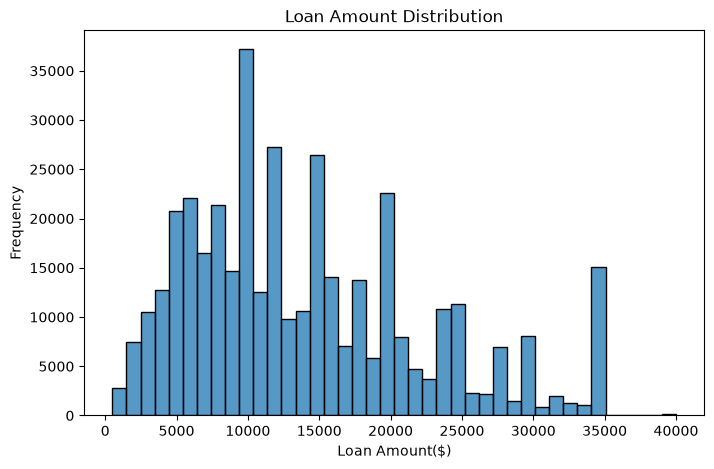

In [205]:
#2. Loan Amount Distribution 

##- Do we issue many small loans or fewer large loans?

plt.figure(figsize=(8,5))
sns.histplot(data=loan_credit, x="loan_amnt", bins=40)

plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount($)")
plt.ylabel("Frequency")

plt.show()

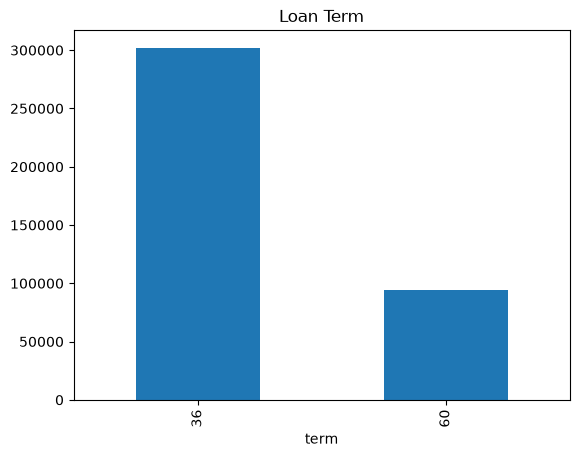

In [206]:
#3. Loan Term Distribution

##- Which repayment plan dominates?
loan_credit['term'].value_counts().plot(
    kind = 'bar')
plt.title("Loan Term")

plt.show()

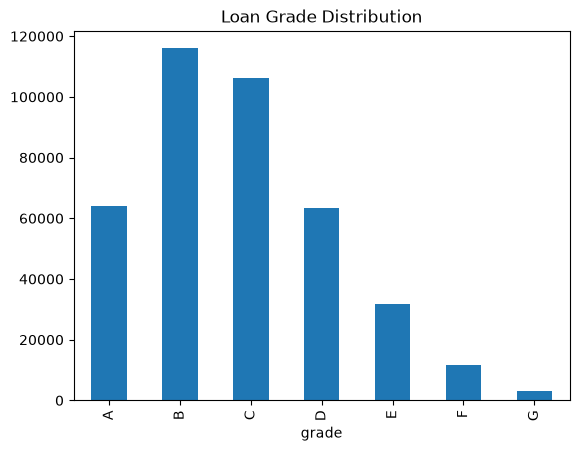

In [207]:
#4. Loan Grade

##-What proportion of the portfolio is high-quality lending?

grade_counts = (loan_credit['grade'].value_counts().sort_index())

grade_counts.plot(kind = "bar")
plt.title("Loan Grade Distribution")
plt.show()

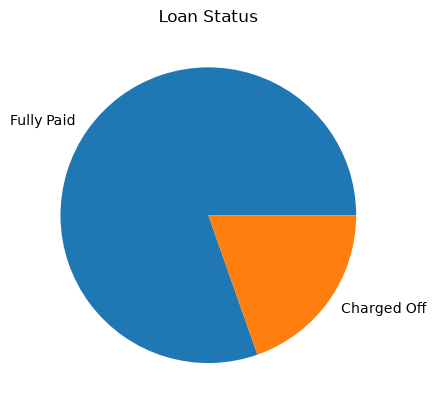

In [208]:
#5.Loan Status

##-What percentage of loans have defaulted?
loan_status = loan_credit['loan_status'].value_counts()
loan_status.plot(kind= "pie")
plt.title("Loan Status")
plt.show()

In [209]:
fully_paid = (loan_credit['loan_status'] == "Fully Paid").mean() * 100
print(f"Percentage of fully paid loans: {fully_paid:.2f}%")

charged_off = (loan_credit['loan_status'] == "Charged Off").mean() * 100
print(f"Percentage of charged off loans: {charged_off:.2f}%")

Percentage of fully paid loans: 80.39%
Percentage of charged off loans: 19.61%


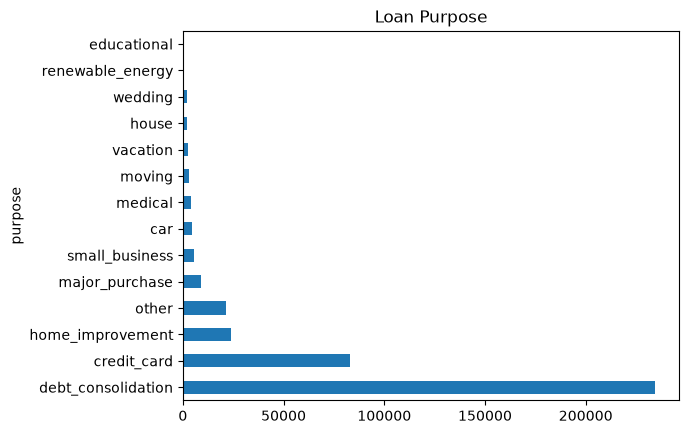

In [210]:
#6.Purpose

##-Why are customers borrowing?
purpose = loan_credit['purpose'].value_counts()
purpose.plot(kind = "barh")
plt.title("Loan Purpose")
plt.show()

/var/folders/x7/xwx5c34s1wd5qfqvv63xy2mm0000gp/T/ipykernel_809/1098646211.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(loan_credit['annual_inc'], vert=False)


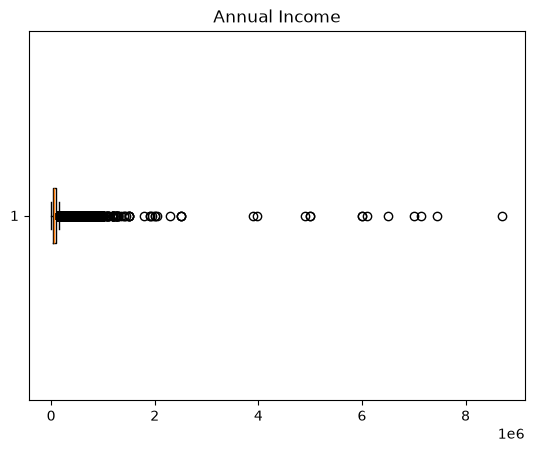

In [211]:
#7.Income

##-Are we lending mostly to high-income customers?
plt.boxplot(loan_credit['annual_inc'], vert=False)
plt.title('Annual Income')
plt.show()

/var/folders/x7/xwx5c34s1wd5qfqvv63xy2mm0000gp/T/ipykernel_809/567926662.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(loan_credit['debt_annual_inc_ratio'], vert=False)


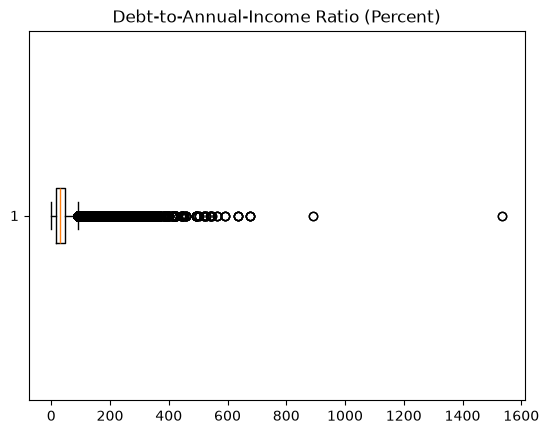

In [212]:
#8.Debt-to-Income

##-Do borrowers generally have manageable debt?
plt.boxplot(loan_credit['debt_annual_inc_ratio'], vert=False)
plt.title("Debt-to-Annual-Income Ratio (Percent)")
plt.show()

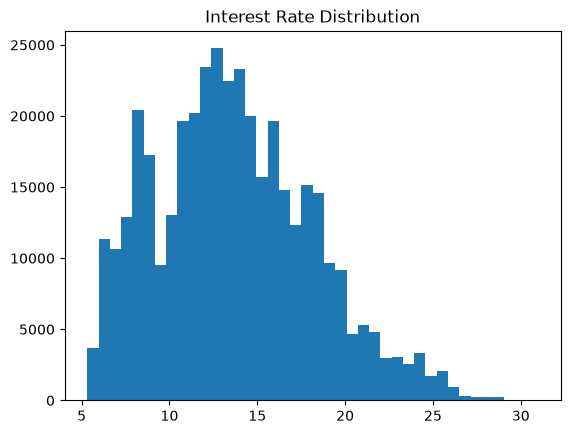

In [213]:
#9.Interest Rate

##-Are most loans low-risk?
plt.hist(loan_credit['int_rate'], bins = 40)
plt.title("Interest Rate Distribution")
plt.show()

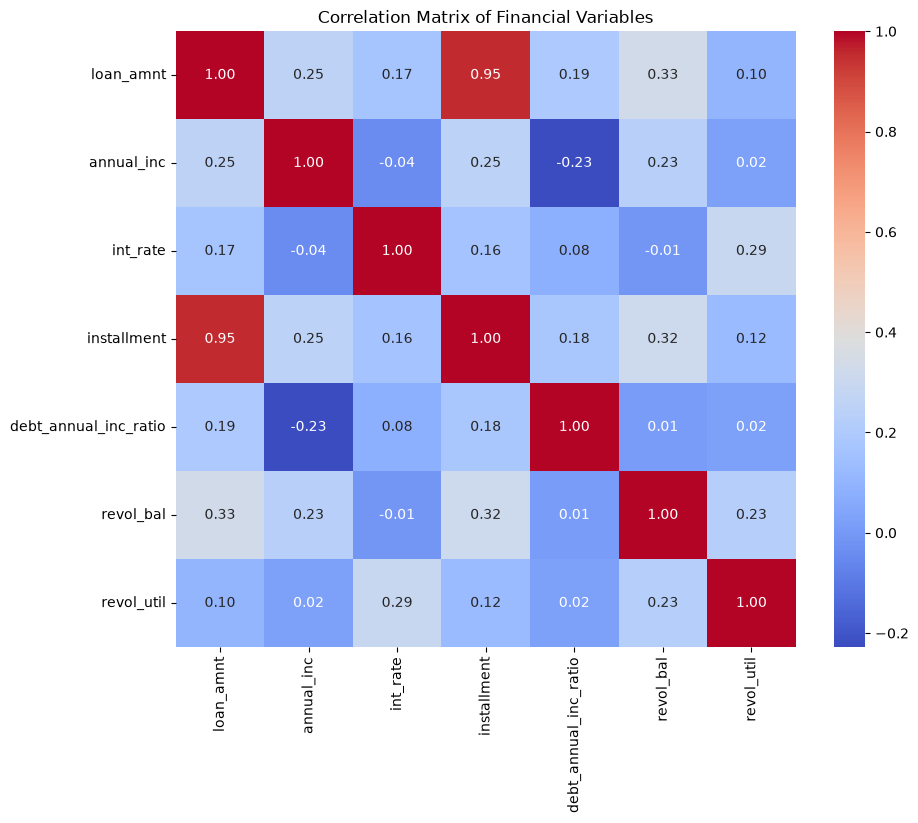

In [214]:
#10.Correlation Matrix

##-Which financial variables move together?
fin_variables = loan_credit[
    [
        "loan_amnt",
        "annual_inc",
        "int_rate",
        "installment",
        "debt_annual_inc_ratio",
        "revol_bal",
        "revol_util"
    ]
]

corr = fin_variables.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
    
plt.title("Correlation Matrix of Financial Variables")
plt.show()

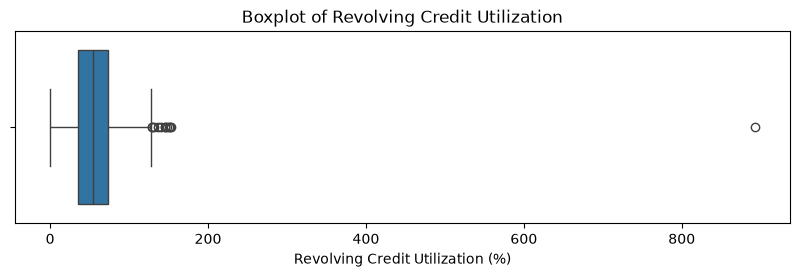

In [215]:
## Revolving Credit Utilization 
plt.figure(figsize=(10, 2.5))

sns.boxplot(
    x=loan_credit["revol_util"]
)

plt.title("Boxplot of Revolving Credit Utilization")
plt.xlabel("Revolving Credit Utilization (%)")

plt.show()

In [216]:
(loan_credit["revol_util"] > 150).sum()

np.int64(4)

In [217]:
loan_credit[loan_credit["revol_util"] > 100]["revol_util"].describe()

count    1167.000000
mean      103.792459
std        23.772862
min       100.100000
25%       100.600000
50%       101.300000
75%       103.100000
max       892.300000
Name: revol_util, dtype: float64

In [218]:
## Revolving credit utilization ranged from 0% to 892.3%. Approximately 0.3% of observations exceeded 100%,
## while only four observations exceeded 150%. These records were retained because they represent a very small proportion
## of the dataset and may reflect borrowers with exceptionally high revolving credit utilization rather than data entry errors.

## Feature Engineering

In [219]:
## Borrower Intelligence

In [220]:
#1. Income Segment (Which income groups receive the most loans?)
loan_credit['income_segment'] = pd.qcut(
    loan_credit['annual_inc'],
    q=4,
    labels=[
        "Low Income",
        "Middle Income",
        "High Income",
        "Very High Income"
    ]
)

In [221]:
#2. Employment Stability
def employment_stability(emp_length):
    if emp_length == "< 1 year":
        return "New"
    elif emp_length in ["1 year", "2 years"]:
        return "Early Career"
    elif emp_length in ["3 years", "4 years"]:
        return "Mid Career"
    elif emp_length in ["5 years", "6 years", "7 years"]:
        return "Experienced"
    elif emp_length in ["8 years", "9 years"]:
        return "Seniorr"
    elif emp_length == "10+ years":
        return "Veteran"
    else: 
        return "Unknown"

loan_credit["employment_stability"] = loan_credit["emp_length"].apply(employment_stability)

In [222]:
#3. Verified Borrowers (Know if verified borrower perform better)
loan_credit["income_verified"] = np.where(
    loan_credit["verification_status"] .isin(
        ["Verified", "Source Verified"]),
    1,
    0
)

In [223]:
#4. Repeat Borrowers
loan_count = loan_credit.groupby("customer_id")["loan_id"].transform("count")

loan_credit["repeat_borrower"] = np.where(
    loan_count > 1,
    1,
    0
)
loan_credit["repeat_borrower"].value_counts()

repeat_borrower
0    220734
1    175295
Name: count, dtype: int64

In [224]:
## Loan Intelligence

In [225]:
#1. Loan Size Category
loan_credit["loan_size"] = pd.qcut(
    loan_credit["loan_amnt"],
    q=4,
    labels=[
        "Small",
        "Medium",
        "Large",
        "Very Large"
    ])
loan_credit["loan_size"].value_counts()

loan_size
Small         112276
Large         111020
Medium         91965
Very Large     80768
Name: count, dtype: int64

In [226]:
#2. Loan to Income Ratio
loan_credit["loan_income_ratio"] = (loan_credit["loan_amnt"] / loan_credit["annual_inc"]).round(2)
loan_credit["loan_income_ratio"].describe()

count    396029.000000
mean          0.223578
std           0.150702
min           0.000000
25%           0.120000
50%           0.200000
75%           0.300000
max           8.580000
Name: loan_income_ratio, dtype: float64

In [227]:
#3. Installment Burden Ratio (based on monthly income)
loan_credit["installment_income_ratio"] = (loan_credit["installment"] / (loan_credit["annual_inc"]/12)).round(2)
loan_credit["installment_income_ratio"].describe()

count    396029.000000
mean          0.082735
std           0.055193
min           0.000000
25%           0.050000
50%           0.070000
75%           0.110000
max           3.540000
Name: installment_income_ratio, dtype: float64

In [228]:
#4. Long Term Loan Flag
loan_credit["long_term_loan"] = np.where(
    loan_credit["term"] == 60,
    1,
    0
)
loan_credit["long_term_loan"].value_counts()

long_term_loan
0    302004
1     94025
Name: count, dtype: int64

In [229]:
## Credit Risk Intelligence 

In [230]:
#1. Default Flag
loan_credit["default_flag"] = np.where(
    loan_credit["loan_status"] == "Charged Off",
    1,
    0)
loan_credit["default_flag"].value_counts()

default_flag
0    318357
1     77672
Name: count, dtype: int64

In [231]:
#2. Credit Utilization Category
def classify_util(revol_util):
    if revol_util <= 30:
        return "Low"
    elif revol_util <= 50:
        return "Moderate"
    elif revol_util <= 75:
        return "High"
    else:
        return "Critical"
loan_credit["credit_utilization"] = loan_credit["revol_util"].apply(classify_util)
loan_credit["credit_utilization"].value_counts()

credit_utilization
High        136532
Moderate     97282
Critical     88132
Low          74083
Name: count, dtype: int64

In [232]:
#3. Credit Experience

In [233]:
loan_credit["total_acc"].describe()

count    396029.000000
mean         25.414758
std          11.887003
min           2.000000
25%          17.000000
50%          24.000000
75%          32.000000
max         151.000000
Name: total_acc, dtype: float64

In [234]:
#Create a function that considers business-defined threshold rather than statistical binning
def classify_credit_history(total_acc):
    if total_acc <= 15:
        return "Limited"
    elif total_acc <= 25:
        return "Growing"
    elif total_acc <= 35:
        return "Established"
    else:
        return "Extensive"
    
loan_credit["credit_experience"] = loan_credit["total_acc"].apply(classify_credit_history)
loan_credit["credit_experience"].value_counts()

credit_experience
Growing        137645
Established    102306
Limited         83521
Extensive       72557
Name: count, dtype: int64

In [235]:
#4. Bankruptcy Risk Flag
loan_credit["bankruptcy_flag"] = np.where(
    loan_credit["pub_rec_bankruptcies"] > 0,
    1,
    0)
loan_credit["bankruptcy_flag"].value_counts()

bankruptcy_flag
0    350665
1     45364
Name: count, dtype: int64

In [236]:
#5. Debt Burden Category

In [237]:
## a. Credit Risk Segmentation (Debt Risk Category) using "DTI"
loan_credit['debt_burden']= pd.cut(
    loan_credit['dti'],
    bins= [0, 10, 20, 40, np.inf],
    labels= [
        'Low',
        'Moderate',
        'High',
        'Critical'],
    include_lowest=True
)
loan_credit['debt_burden'].value_counts()

debt_burden
Moderate    172771
High        143871
Low          79092
Critical       295
Name: count, dtype: int64

In [238]:
## b. Credit Risk Segmentation (Debt Risk Category) using "debt_annual_inc_ratio"
loan_credit['debt_burden_cal']= pd.cut(
    loan_credit["debt_annual_inc_ratio"],
    bins= [0, 20, 40, 60, np.inf],
    labels= [
        'Low',
        'Moderate',
        'High',
        'Critical'],
    include_lowest=True
)
loan_credit['debt_burden_cal'].value_counts()

debt_burden_cal
Moderate    141599
Low         126166
Critical     68624
High         59640
Name: count, dtype: int64

In [239]:
## Portfolio Intelligence

In [240]:
#1. High Value Loan Flag
threshold = loan_credit["loan_amnt"].quantile(0.75)

loan_credit["high_value_loan"] = np.where(
    loan_credit["loan_amnt"] >= threshold,
    1,
    0
)
loan_credit["high_value_loan"].value_counts()

high_value_loan
0    296292
1     99737
Name: count, dtype: int64

In [241]:
#2. Premium Borrower (Borrower with "High income", "Low DTI", "No bankruptcy", "Verified income")
loan_credit["premium_borrower"] = np.where(
    (loan_credit["annual_inc"] >= loan_credit["annual_inc"].quantile(0.75)) &
    (loan_credit["dti"] <= loan_credit["dti"].median()) &
    (loan_credit["bankruptcy_flag"] == 0) &
    (loan_credit["income_verified"] == 1),
    1,
    0
)
loan_credit["premium_borrower"].value_counts()

premium_borrower
0    354882
1     41147
Name: count, dtype: int64

In [242]:
#3. Expected Interest Income
term_years = (
    loan_credit["term"]
    / 12
)
loan_credit["expected_interest_income"] = ((loan_credit["loan_amnt"]) *
                                           (loan_credit["int_rate"] / 100) *
                                           (term_years)).round(2)
loan_credit["expected_interest_income"].describe()

count    396029.000000
mean       7613.142644
std        7488.629325
min         146.400000
25%        2682.000000
50%        4753.680000
75%        9834.300000
max       59980.000000
Name: expected_interest_income, dtype: float64

## KPI ENGINEERING
#### Create Portfolio Performance KPIs, Credit Risk KPIs, Borrower Intelligence KPIs, and Financial Performance KPIs,

In [243]:
## Portfolio Performance KPIs (How large and healthy is the lending portfolio?)

In [244]:
#1. Total Loan Portfolio
total_loan_portfolio = loan_credit["loan_amnt"].sum()
print(f"Total loan portfolio is ${total_loan_portfolio:,.2f}")

Total loan portfolio is $5,589,519,400.00


In [245]:
#2. Total Number of Loans
total_num_loan = len(loan_credit)
print(f"Total number of loans is {total_num_loan:,} loans.")

Total number of loans is 396,029 loans.


In [246]:
#3. Total Number of Unique Borrowers
unique_borrower = loan_credit["customer_id"].nunique()
print(f"Total number of unique borrowers is {unique_borrower:,} customers.")

Total number of unique borrowers is 294,396 customers.


In [247]:
#4. Average Loan Amount
avg_loan_amnt = loan_credit["loan_amnt"].mean()
print(f"Average loan amount is ${avg_loan_amnt:,.2f}")

Average loan amount is $14,113.91


In [248]:
#5. Median Loan Amount
median_loan_amnt = loan_credit["loan_amnt"].median()
print(f"Median loan amount is ${median_loan_amnt:,.2f}")

Median loan amount is $12,000.00


In [249]:
## Credit Risk KPIs (How risky is the portfolio?)

In [250]:
#1. Default Rate
default_rate = (loan_credit["default_flag"].mean() * 100)
print(f"Default rate is {default_rate:.2f}%")

Default rate is 19.61%


In [251]:
#2. Fully Paid Rate
fully_paid_rate = ((loan_credit["loan_status"] == "Fully Paid").mean() * 100)
print(f"Fully paid rate is {fully_paid_rate:.2f}%")

Fully paid rate is 80.39%


In [252]:
#3. High Debt Risk Rate (Borrowers under high and critical categories) -based on raw value
high_debt_rate = (
    ((loan_credit["debt_burden"] == "High") | (loan_credit["debt_burden"] == "Critical")).mean() * 100)
print(f"High Debt Risk Borrowers are {high_debt_rate:.2f}%")

High Debt Risk Borrowers are 36.40%


In [253]:
#- High Debt Risk Rate based on calc value
high_debt_rate_calc = (
    ((loan_credit["debt_burden_cal"] == "High") | (loan_credit["debt_burden_cal"] == "Critical")).mean() * 100)
print(f"High Debt Risk Borrowers are {high_debt_rate_calc:.2f}%")

High Debt Risk Borrowers are 32.39%


In [254]:
#4. Bankruptcy Rate
bankruptcy_rate = (loan_credit["bankruptcy_flag"].mean() * 100)
print(f"Bankruptcy Rate is {bankruptcy_rate:.2f}%")

Bankruptcy Rate is 11.45%


In [255]:
#5. Average Debt-to-Income Ratio
avg_dti = loan_credit["dti"].mean()
print(f"Average Debt-to-Income Ratio is {avg_dti:.2f}")

Average Debt-to-Income Ratio is 17.35


In [256]:
#- Average Debt to Annual Income Ratio
avg_dtai = loan_credit["debt_annual_inc_ratio"].mean()
print(f"Average Debt to Annual Income Ratio is {avg_dtai:.2f}")

Average Debt to Annual Income Ratio is 39.05


In [257]:
#6. Average Revolving Utilization 
avg_revol_util = (loan_credit["revol_util"].mean())
print(f"The average revolving utilization is {avg_revol_util:.2f}%")

The average revolving utilization is 53.79%


In [258]:
## Borrower Intelligence KPIs (Who are we lending to?)

In [259]:
#1. Average Annual Income
avg_annual_inc = (loan_credit["annual_inc"].mean())
print(f"Average Annual Income is ${avg_annual_inc:,.2f}")

Average Annual Income is $74,150.33


In [260]:
#2. Verified Borrower Rate
verified_rate = (loan_credit["income_verified"].mean() * 100)
print(f"Verified Borrower Rate is {verified_rate:.2f}%")

Verified Borrower Rate is 68.30%


In [261]:
#3. Repeat Borrower Rate
repeat_borr_rate = (loan_credit["repeat_borrower"].mean() * 100)
print(f"Repeat Borrower Rate is {repeat_borr_rate:.2f}%")

Repeat Borrower Rate is 44.26%


In [262]:
#4. Premium Borrower Rate
premium_rate = (loan_credit["premium_borrower"].mean() * 100)
print(f"Premium Borrower Rate is {premium_rate:.2f}%")

Premium Borrower Rate is 10.39%


In [263]:
## Financial Performance KPIs (How much revenue is the portfolio expected to generate?)

In [264]:
#1. Average Interest Rate
avg_int_rate = (loan_credit["int_rate"].mean())
print(f"Average Interest Rate is {avg_int_rate:.2f}%")

Average Interest Rate is 13.64%


In [265]:
#2. Estimated Interest Income
est_income = loan_credit["expected_interest_income"].sum()
print(f"The estimatedinterest income is ${est_income:,.2f}")

The estimatedinterest income is $3,015,025,268.31


In [266]:
#3. Average Loan-to-Income Ratio
avg_loan_inc_ratio = (loan_credit["loan_income_ratio"].mean())
print(f"The average loan-to-income ratio is {avg_loan_inc_ratio:.2f}")

The average loan-to-income ratio is 0.22


In [267]:
#4.High-Value Loan Rate
high_value_rate = (loan_credit["high_value_loan"].mean() * 100)
print(f"The high-value loan rate is {high_value_rate:.2f}%")

The high-value loan rate is 25.18%


In [268]:
kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Loan Portfolio",
        "Total Loans",
        "Unique Borrowers",
        "Average Loan Amount",
        "Median Loan Amount",
        "Default Rate (%)",
        "Fully Paid Rate (%)",
        "High Debt Risk Rate (%)",
        "High Debt Risk Rate Calc (%)",
        "Bankruptcy Rate (%)",
        "Average DTI",
        "Average Debt-to-Annual Income Ratio",
        "Average Annual Income",
        "Verified Borrower Rate (%)",
        "Repeat Borrower Rate (%)",
        "Premium Borrower Rate (%)",
        "Average Interest Rate (%)",
        "Estimated Interest Income",
        "Average Loan-to-Income Ratio",
        "High Value Loan Rate (%)"
    ],
    "Value": [
    f"${total_loan_portfolio:,.0f}",
    f"{total_num_loan:,}",
    f"{unique_borrower:,}",
    f"${avg_loan_amnt:,.2f}",
    f"${median_loan_amnt:,.2f}",
    f"{default_rate:.2f}%",
    f"{fully_paid_rate:.2f}%",
    f"{high_debt_rate:.2f}%",
    f"{high_debt_rate_calc:.2f}%",
    f"{bankruptcy_rate:.2f}%",
    f"{avg_dti:.2f}",
    f"{avg_dtai:.2f}",
    f"${avg_annual_inc:,.2f}",
    f"{verified_rate:.2f}%",
    f"{repeat_borr_rate:.2f}%",
    f"{premium_rate:.2f}%",
    f"{avg_int_rate:.2f}%",
    f"${est_income:,.2f}",
    f"{avg_loan_inc_ratio:.2f}",
    f"{high_value_rate:.2f}%"
]
})

kpi_summary

,KPI,Value
0,Total Loan Portfolio,"$5,589,519,400"
1,Total Loans,"396,029"
2,Unique Borrowers,"294,396"
3,Average Loan Amount,"$14,113.91"
4,Median Loan Amount,"$12,000.00"
5,Default Rate (%),19.61%
6,Fully Paid Rate (%),80.39%
7,High Debt Risk Rate (%),36.40%
8,High Debt Risk Rate Calc (%),32.39%
9,Bankruptcy Rate (%),11.45%


In [269]:
##Export updated data as csv file to Tableau for visualization
loan_credit.to_csv("loan_credit_risk_tableau.csv", index=False)

## **Summary**

## **1. Loan Default Risk Dashboard**

Evaluate the overall credit quality of the lending portfolio while identifying borrowers with the highest probability of default.

### **Key Findings**

- **Default Rate** is  **19.6%**
- **Fully Paid Rate** is **80.4%**
- **Grade G** borrowers recorded the highest default rate (**39.5%**), while **Grade A** borrowers remained the safest (**9.6%**).
- Borrowers classified under **Critical Debt Burden** experienced substantially higher default rates.
- **Low-income borrowers (22.8%)** exhibited the highest default risk.
- **Small business loans** recorded the greatest proportion of defaults.
- Employment stability showed relatively small differences, indicating that **financial capacity** is a stronger predictor than employment tenure.

---

## **2. Borrower Segmentation Dashboard**

Understand borrower demographics, financial behaviour, and lending characteristics.

### **Key Findings**

- **Average Annual Income** is **$74,152**
- **Premium Borrowers** is **10.4%**
- Mortgage holders represented approximately **50%** of the lending portfolio.
- Higher-income customers consistently received larger average loan amounts.
- Approximately **75%** of borrowers maintained only one active loan, while **25%** were repeat borrowers.
- Borrower verification status was relatively balanced across the portfolio.

---


## **3. Executive Lending Performance Dashboard**

Evaluate lending performance, portfolio quality, and revenue generation.

### **Key Findings**

- **Total Portfolio Value** is **$5.59 Billion**

- **Estimated Interest Income** is **$3.02 Billion**

- **Grade B** and **Grade C** contributed the largest share of total lending value.
- **Debt Consolidation** generated approximately **$1.95 Billion** in expected interest income.
- Default rates increased progressively from **Grade A** to **Grade G**, validating the effectiveness of the institution's credit grading system.

---

## **4. Loan Performance & Revenue Dashboard**
Assess loan profitability and identify the primary drivers of lending revenue.

### **Key Findings**

- **Average Interest Rate** is **13.6%**
    
- **Average Loan Amount** is **$14.11K**

- **Average Monthly Installment:** is **$431.85**
    
- Longer-term loans generated higher installment values.
- Debt Consolidation remained the largest contributor to expected interest income.
- Interest rates increased consistently across declining credit grades.
- Most issued loans were concentrated within lower loan amount ranges, reducing exposure per individual borrower.

---

## **5. Executive Lending Portfolio Dashboard**
Provide executives with a comprehensive overview of the lending portfolio.

### **Key Findings**

- **Total Loans** is **396,029**

- **Unique Borrowers** are **294,396**

- **Portfolio Value** is **$5.59 Billion**

- **Estimated Interest Income** is **$3.02 Billion**


- High-income borrowers contributed the largest share of lending value.
- Debt Consolidation remained the dominant lending purpose.
- Small and Large loans accounted for the highest lending volumes.

---

# **Discussion**

The analysis demonstrates that **borrower financial capacity, loan grade, income level, and debt burden** are the strongest drivers of loan performance. Although **80.4%** of loans were fully repaid, the **19.6% charged-off rate** represents a significant credit exposure within a **$5.59 billion** lending portfolio.

Default risk increased consistently from **Grade A (9.6%)** to **Grade G (39.5%)**, indicating that the institution's grading methodology effectively differentiates borrower risk. Income segmentation further showed that **low-income borrowers experience disproportionately higher default rates**, while higher-income borrowers contribute more significantly to portfolio value and expected interest income.

The dashboards also revealed that **Debt Consolidation loans generate the largest share of expected interest income**, making them the most profitable lending category. However, the heavy concentration of lending within a single loan purpose introduces **portfolio concentration risk**, highlighting the need for greater diversification.

Overall, the combination of **feature engineering, KPI intelligence, and interactive Tableau dashboards** provides a comprehensive analytical framework for portfolio monitoring and strategic lending decisions.

---

# **Conclusion**

This project delivers a comprehensive **Loan Credit Risk Analytics Framework** by integrating **Python** for data preparation, exploratory analysis, feature engineering, and KPI development with **Tableau** for executive business intelligence.

The analysis confirms that **loan grade, debt burden, income level, and loan purpose** are the primary determinants of borrower repayment performance. These insights enable financial institutions to strengthen underwriting standards, improve portfolio quality, optimize profitability, and proactively manage credit risk.

---


# **Business Recommendations**

#### 1. Implement stricter credit assessment criteria for **Grades E–G**, including enhanced affordability checks and additional income verification.

---

#### 2. Increase lending opportunities for borrowers with strong repayment histories, higher incomes, and lower debt burdens.

---

#### 3. Develop predictive monitoring models using variables such as **Debt Burden, Loan Grade, Income Segment, and Repayment Behaviour** to identify high-risk accounts before default occurs.

---

#### 4. Reduce dependence on **Debt Consolidation loans** by expanding lending across additional loan purposes to minimize concentration risk.

---

#### 5. Align interest rates more closely with borrower risk profiles to improve the balance between profitability and credit risk.

---

#### 6. Develop loyalty programmes and targeted lending offers for premium borrowers to encourage repeat borrowing while maintaining portfolio quality.

---

#### 7. Strengthen borrower verification procedures, particularly for applicants with higher debt burdens or lower credit grades.

---

#### 8. Integrate the Tableau dashboards into routine portfolio reviews to monitor lending performance, detect emerging risks, and support evidence-based strategic decision-making.

---

#### Check Out Visualizations on Tableau:

#### - Loan Default Risk Dashboard: https://surl.li/vntsxm

#### - Borrower Segmentation Dashboard: https://surl.lt/shnnky

#### - Executive Lending Performance Dashboard: https://surl.li/dqvjes 

#### - Loan Performance & Revenue Dashboard: https://surli.cc/xfyjya

#### - Executive Lending Portfolio Dashboard: https://surl.li/czdocv